# 03_regressor_embeddings_only.ipynb

**Baseline Model: RS Embeddings Only**- `total_reviews`: Conteo de interacciones por juego

## Target:

Primer modelo de regresión que predice popularidad (total_reviews) usando SOLO los embeddings del RS.

- RS Embeddings: 64 dimensiones (del notebook 02)

## Objetivo:## Features:

- Establecer baseline de performance con RS embeddings (64-dim)

- Comparar temporal split vs random split- Validar que embeddings RS capturan señal predictiva

In [1]:
import pandas as pd
import numpy as np
import json
import ast

INTERACTIONS = "../Data/interactions.parquet"
USERMAP = "../Data/user2idx.json"
ITEMMAP = "../Data/item2idx.json"
ITEM_EMB = "../Data/item_embeddings_rs.npy"
STEAM_GAMES = "../Data/steam_games.json"

# Load data
df_inter = pd.read_parquet(INTERACTIONS)
item_emb = np.load(ITEM_EMB)

with open(USERMAP,"r") as f: 
    user2idx = {k:int(v) for k,v in json.load(f).items()}
with open(ITEMMAP,"r") as f: 
    item2idx = {k:int(v) for k,v in json.load(f).items()}

# Target: total reviews per game
target_df = df_inter.groupby("item_idx").size().reset_index(name="total_reviews")

# Load game metadata for temporal split
games = []
with open(STEAM_GAMES, 'r', encoding='utf-8') as f:
    for line in f:
        line = line.strip()
        if not line:
            continue
        game = ast.literal_eval(line)
        games.append(game)

df_games = pd.json_normalize(games)
df_games = df_games.rename(columns={"id":"item_id"})
df_games["item_idx"] = df_games["item_id"].map(item2idx)
df_games = df_games.dropna(subset=["item_idx"])
df_games["item_idx"] = df_games["item_idx"].astype(int)

# Parse release dates
df_games['release_date_parsed'] = pd.to_datetime(df_games['release_date'], errors='coerce')

print(f"✅ Data loaded:")
print(f"   RS Embeddings shape: {item_emb.shape}")
print(f"   Total items with interactions: {len(target_df)}")
print(f"   Games with metadata: {len(df_games)}")
print(f"   Games with valid dates: {df_games['release_date_parsed'].notna().sum()}")
print(f"\n📅 Release date range:")
print(f"   Min: {df_games['release_date_parsed'].min()}")
print(f"   Max: {df_games['release_date_parsed'].max()}")

✅ Data loaded:
   RS Embeddings shape: (3682, 64)
   Total items with interactions: 3682
   Games with metadata: 3195
   Games with valid dates: 3107

📅 Release date range:
   Min: 1989-01-01 00:00:00
   Max: 2017-12-25 00:00:00


## Preparar Features y Target

In [2]:
# Preparar X (embeddings) y (total_reviews)
X = item_emb  # shape: (3682, 64)
y = target_df.set_index("item_idx").loc[range(len(item_emb))]["total_reviews"].values

# Merge con metadata para temporal split
item_indices = list(range(len(item_emb)))
data_df = pd.DataFrame({
    'item_idx': item_indices,
    'total_reviews': y
})

data_df = data_df.merge(
    df_games[['item_idx', 'release_date_parsed', 'app_name']],
    on='item_idx',
    how='left'
)

print(f"\n✅ Dataset prepared:")
print(f"   X shape: {X.shape}")
print(f"   y shape: {y.shape}")
print(f"   Target range: {y.min()} - {y.max()}")
print(f"   Target mean: {y.mean():.1f}")
print(f"   Items with dates: {data_df['release_date_parsed'].notna().sum()}")


✅ Dataset prepared:
   X shape: (3682, 64)
   y shape: (3682,)
   Target range: 1 - 3759
   Target mean: 16.1
   Items with dates: 3107


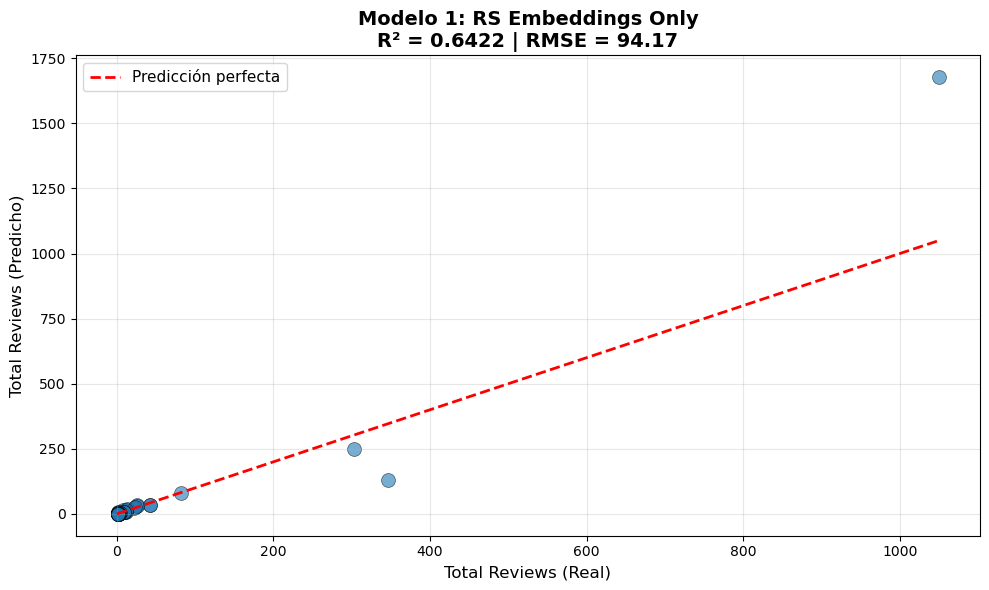


📊 RESUMEN - Modelo 1: RS Embeddings Only
Features: Item embeddings del RS (64 dimensiones)
Train: 3057 juegos (antes de 2017-01-01)
Test: 50 juegos (2017 en adelante)

Resultados:
  R² = 0.6422
  RMSE = 94.17


In [4]:
import matplotlib.pyplot as plt

# Crear gráfico de predicciones
plt.figure(figsize=(10, 6))
plt.scatter(y_test_temporal, pred_temporal, alpha=0.6, s=100, edgecolors='k', linewidth=0.5)
plt.plot([0, y_test_temporal.max()], [0, y_test_temporal.max()], 'r--', lw=2, label='Predicción perfecta')
plt.xlabel('Total Reviews (Real)', fontsize=12)
plt.ylabel('Total Reviews (Predicho)', fontsize=12)
plt.title(f'Modelo 1: RS Embeddings Only\nR² = {r2_temporal:.4f} | RMSE = {rmse_temporal:.2f}', fontsize=14, fontweight='bold')
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print("\n" + "="*70)
print("📊 RESUMEN - Modelo 1: RS Embeddings Only")
print("="*70)
print(f"Features: Item embeddings del RS (64 dimensiones)")
print(f"Train: {len(X_train_temporal)} juegos (antes de 2017-01-01)")
print(f"Test: {len(X_test_temporal)} juegos (2017 en adelante)")
print(f"\nResultados:")
print(f"  R² = {r2_temporal:.4f}")
print(f"  RMSE = {rmse_temporal:.2f}")
print("="*70)

## Visualización de Resultados

In [3]:
from sklearn.metrics import mean_squared_error, r2_score
from xgboost import XGBRegressor

# Define temporal cutoff
cutoff_date = pd.to_datetime('2017-01-01')

# Create temporal train/test split
train_mask = data_df['release_date_parsed'] < cutoff_date
test_mask = data_df['release_date_parsed'] >= cutoff_date

# Remove items without valid dates
valid_dates_mask = data_df['release_date_parsed'].notna()
train_mask = train_mask & valid_dates_mask
test_mask = test_mask & valid_dates_mask

X_train_temporal = X[train_mask]
X_test_temporal = X[test_mask]
y_train_temporal = y[train_mask]
y_test_temporal = y[test_mask]

print(f"{'='*70}")
print("TEMPORAL SPLIT SUMMARY")
print(f"{'='*70}")
print(f"Cutoff date: {cutoff_date.date()}")
print(f"Train set: {len(X_train_temporal)} games (released before {cutoff_date.date()})")
print(f"Test set: {len(X_test_temporal)} games (released after {cutoff_date.date()})")
print(f"Train target: {y_train_temporal.min():.0f} - {y_train_temporal.max():.0f} (mean: {y_train_temporal.mean():.1f})")
print(f"Test target: {y_test_temporal.min():.0f} - {y_test_temporal.max():.0f} (mean: {y_test_temporal.mean():.1f})")
print(f"{'='*70}\n")

# Train model on temporal split
model_temporal = XGBRegressor(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=6,
    random_state=42
)

print("Training model on games released before cutoff...")
model_temporal.fit(X_train_temporal, y_train_temporal)

pred_temporal = model_temporal.predict(X_test_temporal)

mse_temporal = mean_squared_error(y_test_temporal, pred_temporal)
rmse_temporal = np.sqrt(mse_temporal)
r2_temporal = r2_score(y_test_temporal, pred_temporal)

print("\n" + "="*70)
print("RS EMBEDDINGS ONLY - TEMPORAL VALIDATION")
print("="*70)
print(f"RMSE: {rmse_temporal:.2f}")
print(f"R²: {r2_temporal:.6f}")
print("="*70)

TEMPORAL SPLIT SUMMARY
Cutoff date: 2017-01-01
Train set: 3057 games (released before 2017-01-01)
Test set: 50 games (released after 2017-01-01)
Train target: 1 - 3759 (mean: 15.8)
Test target: 1 - 1050 (mean: 42.1)

Training model on games released before cutoff...

RS EMBEDDINGS ONLY - TEMPORAL VALIDATION
RMSE: 94.17
R²: 0.642199


## Train Model - TEMPORAL SPLIT

**Estrategia de validación temporal:**
- Train: Juegos lanzados ANTES de 2017-01-01
- Test: Juegos lanzados DESPUÉS (todo 2017)

In [6]:
from sklearn.metrics import mean_squared_error, r2_score
from xgboost import XGBRegressor

# Define temporal cutoff
cutoff_date = pd.to_datetime('2017-01-01')

# Create temporal train/test split
train_mask = data_df['release_date_parsed'] < cutoff_date
test_mask = data_df['release_date_parsed'] >= cutoff_date

# Remove items without valid dates
valid_dates_mask = data_df['release_date_parsed'].notna()
train_mask = train_mask & valid_dates_mask
test_mask = test_mask & valid_dates_mask

X_train_temporal = X[train_mask]
X_test_temporal = X[test_mask]
y_train_temporal = y[train_mask]
y_test_temporal = y[test_mask]

print(f"{'='*70}")
print("TEMPORAL SPLIT SUMMARY")
print(f"{'='*70}")
print(f"Cutoff date: {cutoff_date.date()}")
print(f"Train set: {len(X_train_temporal)} games (released before {cutoff_date.date()})")
print(f"Test set: {len(X_test_temporal)} games (released after {cutoff_date.date()})")
print(f"Train target: {y_train_temporal.min():.0f} - {y_train_temporal.max():.0f} (mean: {y_train_temporal.mean():.1f})")
print(f"Test target: {y_test_temporal.min():.0f} - {y_test_temporal.max():.0f} (mean: {y_test_temporal.mean():.1f})")
print(f"{'='*70}\\n")

# Train model on temporal split
model_temporal = XGBRegressor(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=6,
    random_state=42
)

print("Training model on games released before cutoff...")
model_temporal.fit(X_train_temporal, y_train_temporal)

pred_temporal = model_temporal.predict(X_test_temporal)

mse_temporal = mean_squared_error(y_test_temporal, pred_temporal)
rmse_temporal = np.sqrt(mse_temporal)
r2_temporal = r2_score(y_test_temporal, pred_temporal)

print("\\n" + "="*70)
print("RS EMBEDDINGS ONLY - TEMPORAL VALIDATION")
print("="*70)
print(f"RMSE: {rmse_temporal:.2f}")
print(f"R²: {r2_temporal:.6f}")
print("="*70)

TEMPORAL SPLIT SUMMARY
Cutoff date: 2017-01-01
Train set: 3057 games (released before 2017-01-01)
Test set: 50 games (released after 2017-01-01)
Train target: 1 - 3759 (mean: 15.8)
Test target: 1 - 1050 (mean: 42.1)
======================================================================\n
Training model on games released before cutoff...
\n======================================================================
RS EMBEDDINGS ONLY - TEMPORAL VALIDATION
RMSE: 94.17
R²: 0.642199
